# Regional_SA

In [1]:
import earthaccess
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import sys,os,glob,datetime
import cartopy.crs as ccrs
import cartopy.crs as crs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings("ignore")

### Downloading Data

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
bbox = (-180, -90, 180, 90)
tspan = ("2025-07-01", "2025-07-10")

results_OCI = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CLOUD_NRT",
    bounding_box=bbox,    
    temporal=tspan,
    granule_name="*.DAY.*.0p1deg.*"
)

In [4]:
bbox = (-180, -90, 180, 90)
tspan = ("2025-07-01", "2025-07-10")

results_HARP2 = earthaccess.search_data(
    short_name="PACE_HARP2_L3M_CLOUD_GPC_NRT",
    bounding_box=bbox,    
    temporal=tspan,
    granule_name="*.DAY.*.0p1deg.*"
)

In [5]:
files_OCI = earthaccess.download(results_OCI, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_NRT")

QUEUEING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/20 [00:00<?, ?it/s]

In [6]:
files_HARP2 = earthaccess.download(results_HARP2, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_NRT")

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
# files_OCI

In [8]:
# files_HARP2

### Opening Data

In [2]:
def ds_slicing(ds, bounding_box = (-88.02, -32.16, -58.14, -9.29)):
    datetime = ds.attrs["time_coverage_start"].replace("Z", "")
    time = np.datetime64(datetime, "ns")
    ds = ds.assign_coords(time=[time])
    return (ds.sel(lat=slice(bounding_box[3], bounding_box[1]), lon=slice(bounding_box[0], bounding_box[2])))

In [3]:
dataset_OCI = xr.open_mfdataset("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/*.V3_0.*.nc", preprocess=ds_slicing)
# dataset_OCI

In [4]:
dataset_HARP2 = xr.open_mfdataset("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0/*.V3_0.*.nc", preprocess=ds_slicing)
# dataset_HARP2

In [6]:
OCI_CER = dataset_OCI['cer_21_water'].values 
OCI_COT = dataset_OCI['cot_21_water'].values
HARP2_CER = dataset_HARP2['cloud_bow_droplet_effective_radius'].values

mask_all = (HARP2_CER > 0) & (OCI_CER > 0)

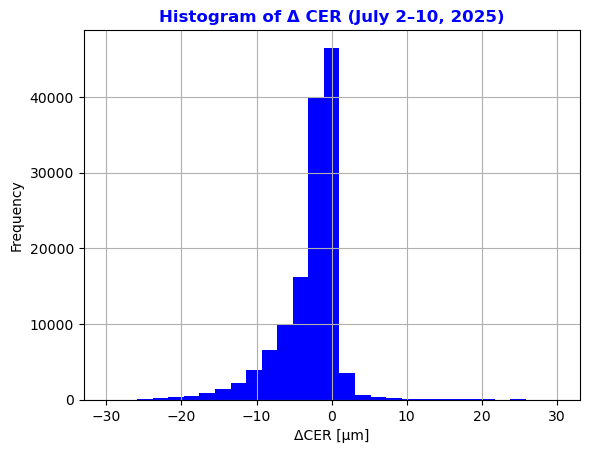

In [7]:
delta_CER = HARP2_CER[mask_all] - OCI_CER[mask_all]
plt.hist(delta_CER, bins=np.linspace(-30, 30, 30, endpoint=True), color='b')     
plt.xlabel("ΔCER [µm]")
plt.ylabel("Frequency")
plt.title(f"Histogram of Δ CER (July 2–10, 2025)", fontsize=12, color="b", fontweight="bold")
plt.grid(True)
# plt.savefig('Histogram_Delta_CER.png', dpi=300)
plt.show()

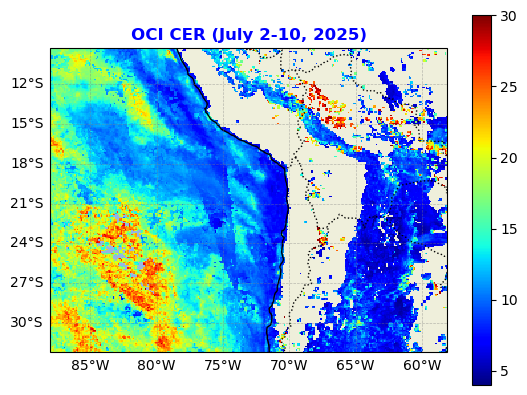

In [8]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap='jet'

data = np.where(mask_all, OCI_CER, np.nan)
mean_data = np.nanmean(data, axis=0)
mat = ax.pcolormesh(dataset_OCI.lon, dataset_OCI.lat, mean_data, transform=ccrs.PlateCarree(), 
                    cmap=cmap, vmin=4, vmax=30, shading="nearest", rasterized=True)
# mat = ax.pcolormesh(dataset_OCI.lon, dataset_OCI.lat, data[1,:,:], transform=ccrs.PlateCarree(), 
#                     cmap=cmap, vmin=4, vmax=30, shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('OCI CER (July 2-10, 2025)', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax)
plt.show()

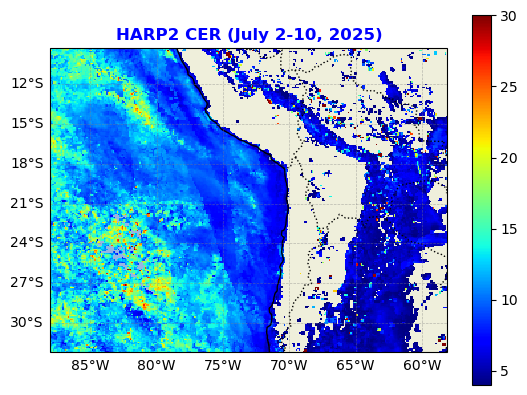

In [9]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap='jet'

data = np.where(mask_all, HARP2_CER, np.nan)
mean_data = np.nanmean(data, axis=0)
mat = ax.pcolormesh(dataset_OCI.lon, dataset_OCI.lat, mean_data, transform=ccrs.PlateCarree(), 
                    cmap=cmap, vmin=4, vmax=30, shading="nearest", rasterized=True)
# mat = ax.pcolormesh(dataset_OCI.lon, dataset_OCI.lat, data[1,:,:], transform=ccrs.PlateCarree(), 
#                     cmap=cmap, vmin=4, vmax=30, shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 CER (July 2-10, 2025)', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax)
plt.show()

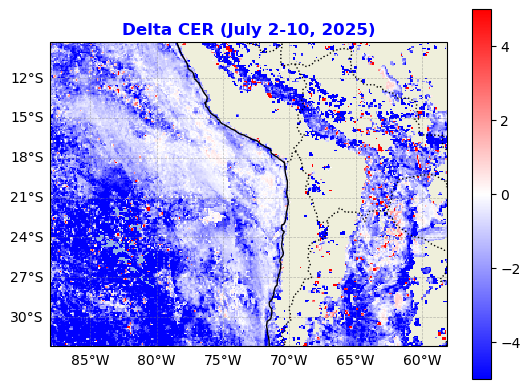

In [10]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap='bwr'

OCI_CER = np.where(mask_all, OCI_CER, np.nan)
HARP2_CER = np.where(mask_all, HARP2_CER, np.nan)
delta_CER = HARP2_CER - OCI_CER

data = np.where(mask_all, delta_CER, np.nan)
mean_data = np.nanmean(data, axis=0)

mat = ax.pcolormesh(dataset_OCI.lon, dataset_OCI.lat, mean_data, transform=ccrs.PlateCarree(), 
                    cmap=cmap, vmin=-5, vmax=5, shading="nearest", rasterized=True)
# mat = ax.pcolormesh(dataset_OCI.lon, dataset_OCI.lat, data[0,:,:], transform=ccrs.PlateCarree(), 
#                     cmap=cmap, vmin=-5, vmax=5, shading="nearest", rasterized=True)
ax.set_aspect("equal")
ax.set_aspect("equal")
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Delta CER (July 2-10, 2025)', fontsize=12, color='b', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
cax = plt.colorbar(mat, ax=ax)
# plt.savefig('Map_Delta_CER.png', dpi=300)
plt.show()

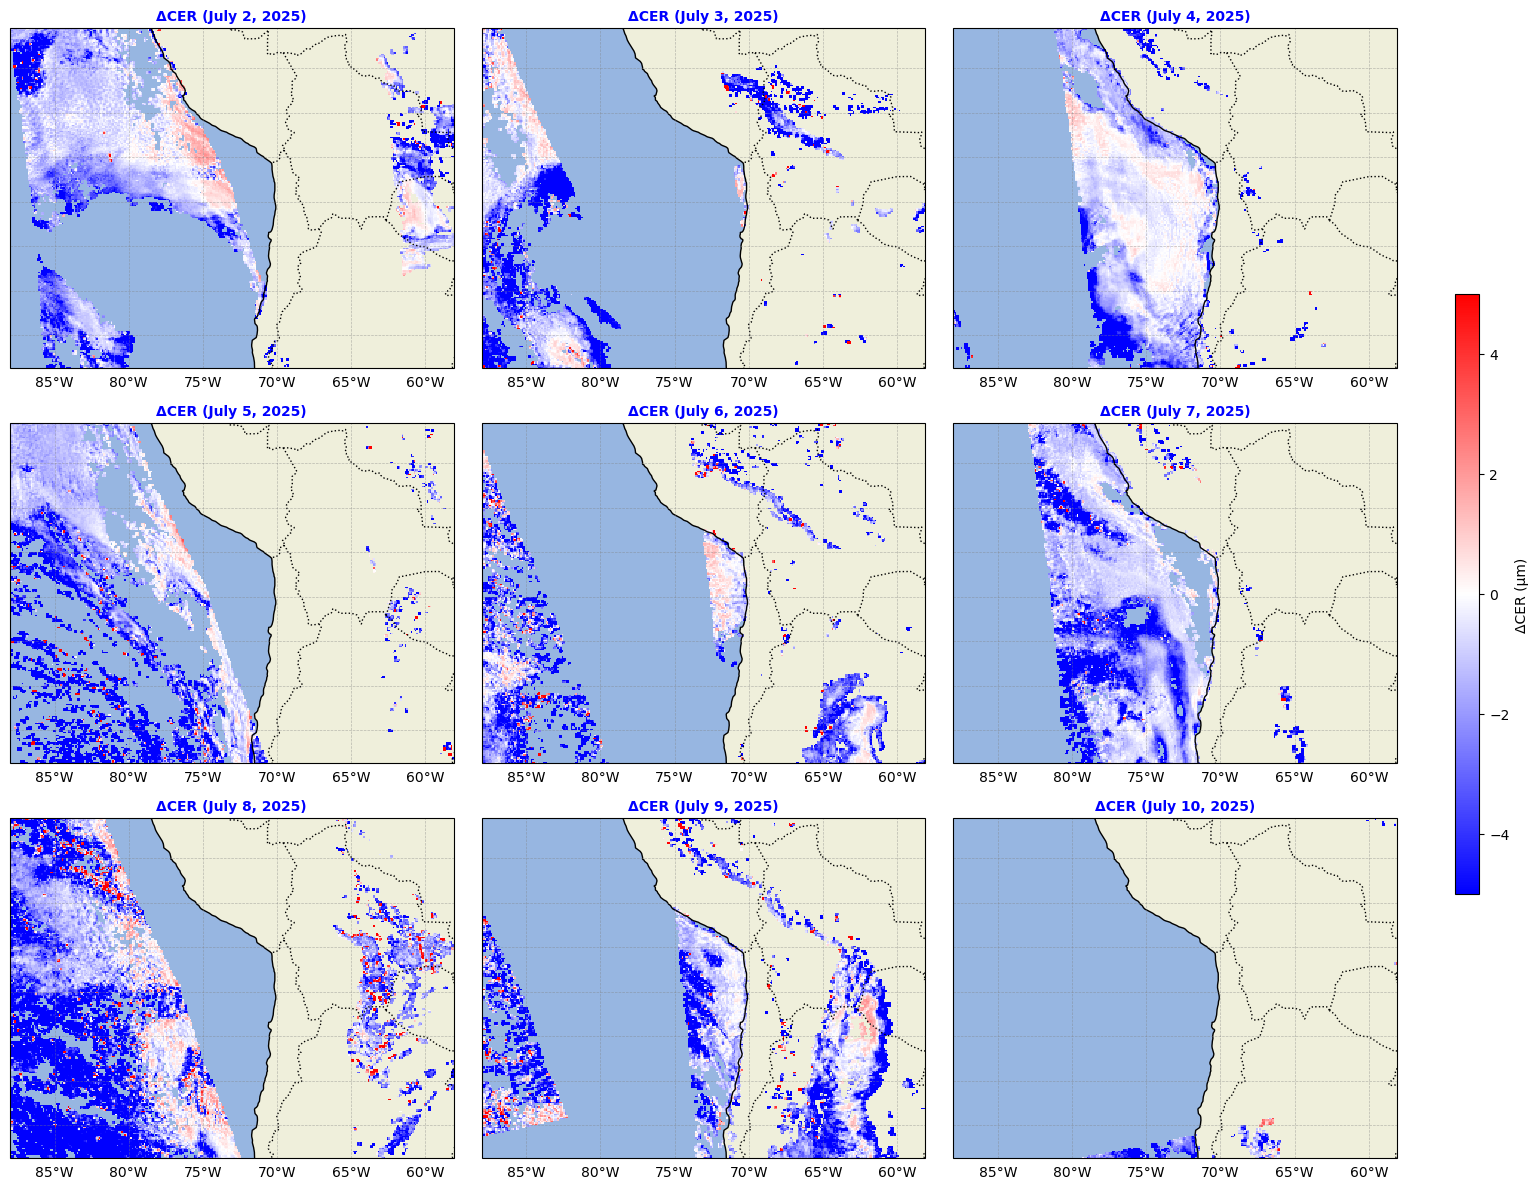

In [11]:
OCI_CER = np.where(mask_all, OCI_CER, np.nan)
HARP2_CER = np.where(mask_all, HARP2_CER, np.nan)
delta_CER = HARP2_CER - OCI_CER   

dates = [f"July {d}, 2025" for d in range(2, 11)]  # July 2–10
fig, axes = plt.subplots(3, 3, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
cmap = "bwr"

for i, ax in enumerate(axes.flat):
    data_day = delta_CER[i, :, :]   
    mat = ax.pcolormesh(dataset_OCI.lon, dataset_OCI.lat, data_day, transform=ccrs.PlateCarree(), 
                        cmap=cmap, vmin=-5, vmax=5, shading="nearest", rasterized=True)

    # Add map features
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.set_title(f"ΔCER ({dates[i]})", fontsize=10, color="b", fontweight="bold")

    gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False

# Add one colorbar for all plots
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])           # [left, bottom, width, height]
fig.colorbar(mat, cax=cbar_ax, label="ΔCER (µm)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig('Delta_CER_days.png', dpi=300)
plt.show()

In [12]:
OCI_CER = OCI_CER[mask_all]            
HARP2_CER = HARP2_CER[mask_all]     
delta_CER = HARP2_CER - OCI_CER

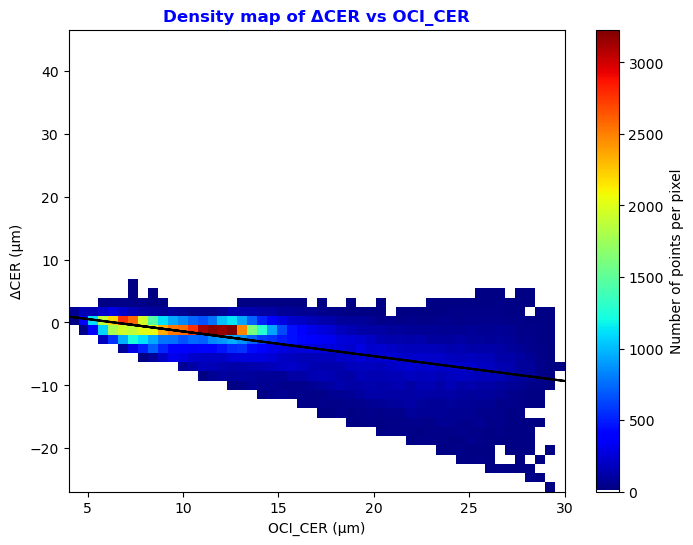

In [13]:
original_jet = plt.cm.get_cmap('jet', 256)
new_colors = original_jet(np.linspace(0, 1, 256))
new_colors[0, :] = np.array([1, 1, 1, 1])
white_jet_cmap = ListedColormap(new_colors)

def using_hist2d(fig, ax, x, y, bins=(50, 50)):
    h, xedges, yedges, im = ax.hist2d(x, y, bins=bins, cmap=white_jet_cmap)
    fig.colorbar(im, ax=ax, label='Number of points per pixel')

fig, ax = plt.subplots(figsize=(8,6))
using_hist2d(fig, ax, OCI_CER, delta_CER, bins=(50, 50))

# best fit
coefficients = np.polyfit(OCI_CER, delta_CER, 1)
line_of_best_fit = np.poly1d(coefficients)
plt.plot(OCI_CER, line_of_best_fit(OCI_CER), color='k')

ax.set_xlabel("OCI_CER (µm)")
ax.set_ylabel("ΔCER (µm)")
ax.set_title("Density map of ΔCER vs OCI_CER", fontsize=12, color="b", fontweight="bold")
# plt.savefig('Density_map.png', dpi=300)
plt.show()

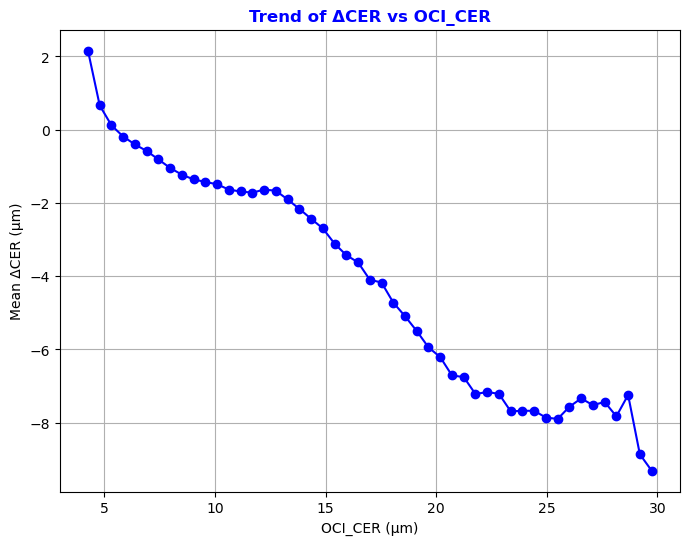

In [14]:
# Define bins across OCI_CER range
bins = np.linspace(OCI_CER.min(), OCI_CER.max(), 50)  # 50 bins
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Compute mean ΔCER in each bin
bin_means = [delta_CER[(OCI_CER >= bins[i]) & (OCI_CER < bins[i+1])].mean()
             for i in range(len(bins)-1)]

plt.figure(figsize=(8,6))
plt.plot(bin_centers, bin_means, marker='o', linestyle='-', color='b')
plt.xlabel("OCI_CER (µm)")
plt.ylabel("Mean ΔCER (µm)")
plt.title("Trend of ΔCER vs OCI_CER", fontsize=12, color="b", fontweight="bold")
plt.grid(True)
plt.show()